# Bài tập thực hành chính quy: Xử lý ảnh và thị giác máy tính

Notebook này là học liệu hướng dẫn và khung làm bài cho hai chủ đề:

1. Hình thái học toán học.
2. Biến đổi hình học và chống răng cưa (anti-aliasing).

Phiên bản này yêu cầu sinh viên **tự viết nhiều thành phần nền tảng**, thay vì chỉ gọi các hàm trợ giúp có sẵn. Mục tiêu là buộc sinh viên hiểu bản chất của phép toán thay vì chỉ quan sát đầu ra.


# Thiết lập chung


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    cv2 = None

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'


In [2]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Ảnh kiểm thử


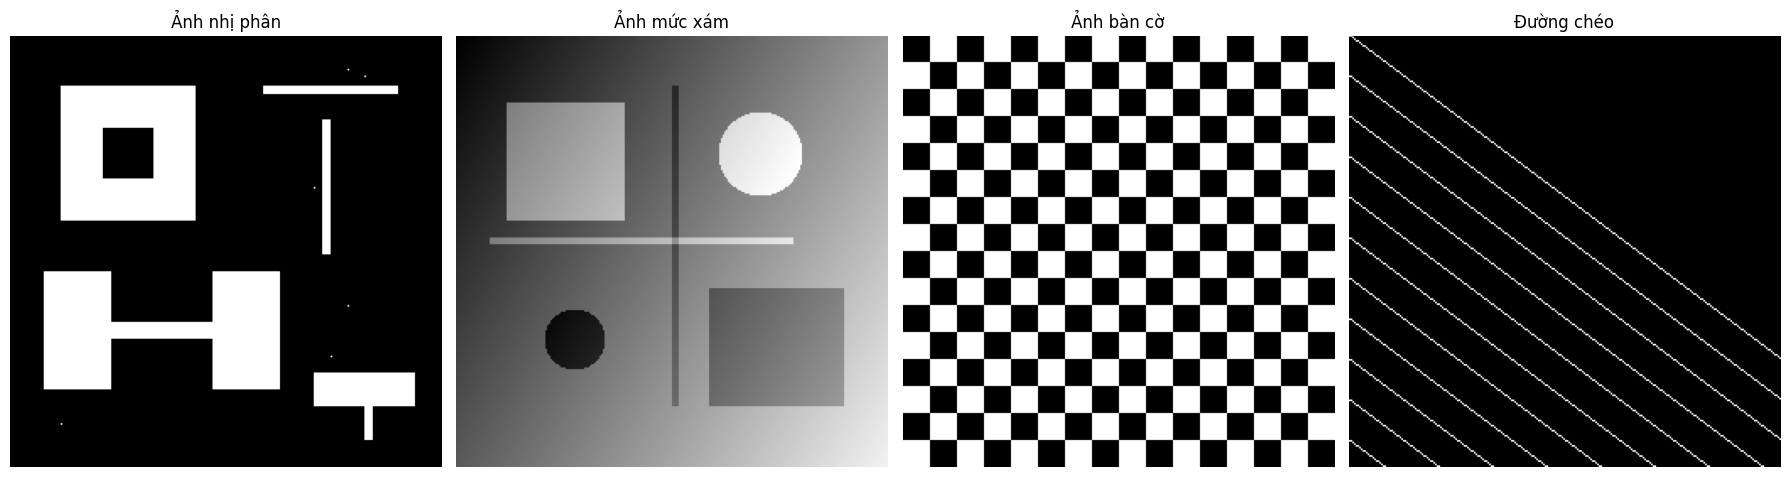

In [3]:
def make_binary_test_image(size=256):
    img = np.zeros((size, size), dtype=np.uint8)
    img[30:110, 30:110] = 255
    img[55:85, 55:85] = 0
    img[140:210, 20:60] = 255
    img[170:180, 60:120] = 255
    img[140:210, 120:160] = 255
    img[30:35, 150:230] = 255
    img[50:130, 185:190] = 255
    img[200:220, 180:240] = 255
    img[220:240, 210:215] = 255
    noise_points = [(20, 200), (24, 210), (90, 180), (160, 200), (190, 190), (230, 30)]
    for r, c in noise_points:
        img[r, c] = 255
    return img


def make_grayscale_test_image(size=256):
    y, x = np.mgrid[0:size, 0:size]
    base = 40 + 0.5 * x + 0.3 * y
    img = base.astype(np.float32)
    img[40:110, 30:100] += 80
    img[150:220, 150:230] -= 50
    rr = (x - 180) ** 2 + (y - 70) ** 2
    img[rr < 25**2] += 90
    img[(x - 70) ** 2 + (y - 180) ** 2 < 18**2] -= 70
    img[120:124, 20:200] += 60
    img[30:220, 128:132] -= 40
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)


def make_checkerboard(size=256, block=16):
    y, x = np.indices((size, size))
    board = ((x // block + y // block) % 2) * 255
    return board.astype(np.uint8)


def make_diagonal_lines(size=256):
    """Ảnh với nhiều đường chéo mảnh -- đặc biệt nhạy cảm với răng cưa."""
    img = np.zeros((size, size), dtype=np.uint8)
    for k in range(0, size, 24):
        for t in range(size):
            r = k + t * 3 // 4
            c = t
            if 0 <= r < size:
                img[r, c] = 255
    return img


binary_img = make_binary_test_image()
grayscale_img = make_grayscale_test_image()
checkerboard_img = make_checkerboard()
diagonal_img = make_diagonal_lines()

show_images(
    [binary_img, grayscale_img, checkerboard_img, diagonal_img],
    titles=['Ảnh nhị phân', 'Ảnh mức xám', 'Ảnh bàn cờ', 'Đường chéo'],
    cols=4,
    figsize=(18, 5)
)


# Bài tập 1: Hình thái học toán học

## Yêu cầu trọng tâm

Sinh viên phải tự viết:

- hàm tạo phần tử cấu trúc,
- hàm padding cho ảnh nhị phân,
- các phép erosion, dilation, opening, closing, gradient.

## Quy ước phần tử cấu trúc

Chỉ dùng ba họ:

- `rectangle`: gồm vuông, ngang, dọc,
- `cross`,
- `ellipse`.

Không dùng `diamond`.


## Việc sinh viên phải làm

1. Tự cài đặt hàm sinh phần tử cấu trúc theo kích thước bất kỳ hợp lệ.
2. Với `rectangle`, phải hỗ trợ cả trường hợp vuông, chữ nhật ngang, chữ nhật dọc.
3. Tự cài đặt padding cho ảnh nhị phân.
4. Tự cài đặt erosion, dilation, opening, closing, gradient.
5. Thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên cung cấp.


In [4]:
# TODO: Sinh viên tự viết hàm padding cho ảnh nhị phân

def pad_binary_image_manual(img, pad_h, pad_w, mode='constant'):
    # Yêu cầu tối thiểu:
    # - Hỗ trợ mode='constant'
    # - Có thể mở rộng thêm mode khác nếu muốn
    h, w = img.shape
    
    padded = np.zeros(
        (h + 2 * pad_h, w + 2 * pad_w),
        dtype=np.uint8
    )

    padded[
        pad_h: pad_h + h,
        pad_w: pad_w + w
    ] = img

    return padded
    
    raise NotImplementedError



In [5]:
img = np.array([
    [1, 1],
    [0, 1]
], dtype=np.uint8)

padded = pad_binary_image_manual(img, 1, 1)

print(padded)

[[0 0 0 0]
 [0 1 1 0]
 [0 0 1 0]
 [0 0 0 0]]


In [8]:
# TODO: Sinh viên tự viết hàm tạo phần tử cấu trúc

def make_structuring_element(shape, ksize):
    # shape thuộc một trong ba giá trị: 'rectangle', 'cross', 'ellipse'
    # ksize là bộ (height, width)
    h,w = ksize

    # Rectangle
    if shape == 'rectangle':
        kernel = np.ones((h, w), dtype=np.uint8)
        return kernel
    
    # cross
    elif shape == 'cross':
        kernel = np.zeros((h, w), dtype=np.uint8)

        center_y = h // 2
        center_x = w // 2

        kernel[center_y, :] = 1
        kernel[: ,center_x] = 1

        return kernel
    
    # ellipes
    elif shape == 'ellipse':
        kernel = np.zeros((h, w), dtype=np.uint8)

        # tâm
        cy = h // 2
        cx = w // 2

        # bán kính
        a = w // 2
        b = h // 2

        # duyệt từng pixel
        for y in range(h):
            for x in range(w):

                # phương trình ellipse
                value = (((x - cx) ** 2) / (a * a + 1e-5) + ((y - cy) ** 2) / (b * b + 1e-5))

                # nếu nằm trong ellipse
                if value <= 1:

                    kernel[y, x] = 1
        return kernel



In [9]:
print(
    make_structuring_element(
        'rectangle',
        (3,3)
    )
)
print(
    make_structuring_element(
        'rectangle',
        (2,5)
    )
)
print(
    make_structuring_element(
        'rectangle',
        (5,3)
    )
)
print(
    make_structuring_element(
        'cross',
        (5,5)
    )
)
print(make_structuring_element('epllipse', (5,5)))

[[1 1 1]
 [1 1 1]
 [1 1 1]]
[[1 1 1 1 1]
 [1 1 1 1 1]]
[[1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]]
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]
None


In [8]:
# TODO: Sinh viên tự hoàn thiện các phép toán hình thái học

# EROSION
def erosion_binary(img, se):

    # kernel shape
    kh, kw = se.shape

    # padding
    pad_h = kh // 2
    pad_w = kw // 2

    # padding image
    padded = pad_binary_image_manual(
        img,
        pad_h,
        pad_w
    )

    # image shape
    h, w = img.shape

    # output
    output = np.zeros_like(img)

    # scan image
    for y in range(h):
        for x in range(w):

            # local region
            region = padded[
                y:y+kh,
                x:x+kw
            ]

            # pixels where kernel = 1
            selected = region[se == 1]

            # erosion:
            # all selected pixels must be foreground
            if np.all(selected > 0):

                output[y, x] = 255

    return output

# DILATION
def dilation_binary(img, se):

    # kernel shape
    kh, kw = se.shape

    # padding
    pad_h = kh // 2
    pad_w = kw // 2

    # padding image
    padded = pad_binary_image_manual(
        img,
        pad_h,
        pad_w
    )

    # image shape
    h, w = img.shape

    # output
    output = np.zeros_like(img)

    # scan image
    for y in range(h):
        for x in range(w):

            # local region
            region = padded[
                y:y+kh,
                x:x+kw
            ]

            # pixels where kernel = 1
            selected = region[se == 1]

            # dilation:
            # need at least one foreground pixel
            if np.any(selected > 0):

                output[y, x] = 255

    return output


# OPENING
# erosion -> dilation

def opening_binary(img, se):

    eroded = erosion_binary(img, se)

    opened = dilation_binary(eroded, se)

    return opened


# CLOSING
# dilation -> erosion

def closing_binary(img, se):

    dilated = dilation_binary(img, se)

    closed = erosion_binary(dilated, se)

    return closed


# MORPHOLOGICAL GRADIENT
# dilation - erosion

def morphological_gradient_binary(img, se):

    dilated = dilation_binary(img, se)

    eroded = erosion_binary(img, se)

    gradient = dilated - eroded

    return gradient


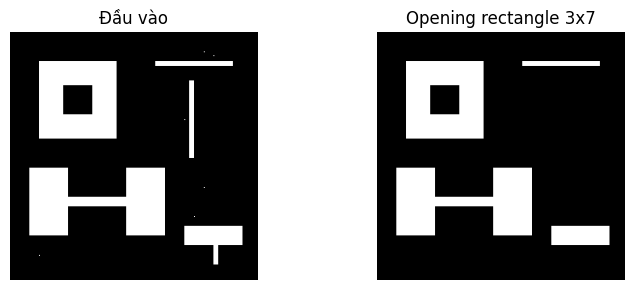

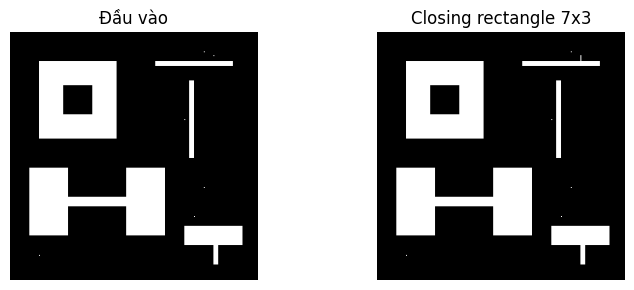

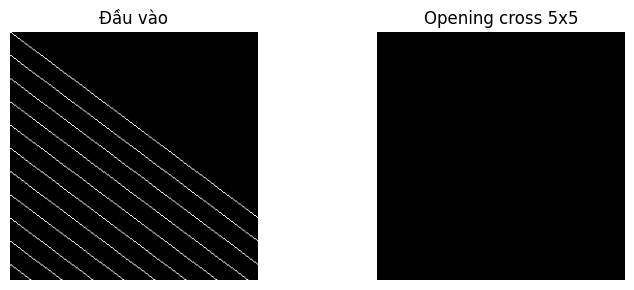

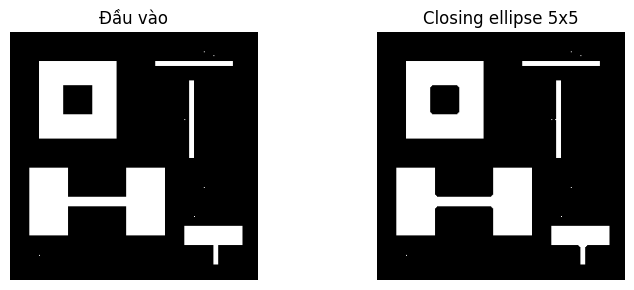

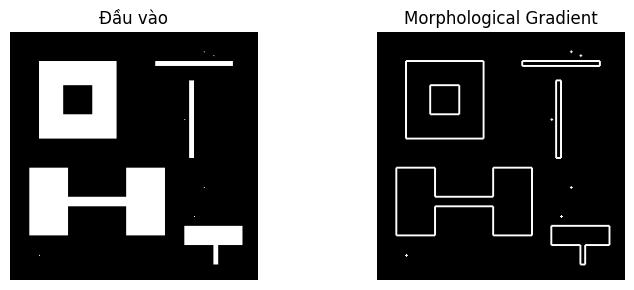

In [ ]:
# Ô thực hành gợi ý
# Sau khi hoàn thiện các hàm ở trên, sinh viên tự chạy các thử nghiệm ở đây.

# Ví dụ khung:
# se = make_structuring_element('rectangle', (3, 7))
# out = opening_binary(binary_img, se)
# show_images([binary_img, out], ['Đầu vào', 'Opening với rectangle 3x7'])

# Rectengle
se = make_structuring_element('rectangle', (3,7))

out = opening_binary(binary_img, se)

show_images([binary_img, out], ['Đầu vào','Opening rectangle 3x7'], cols=2, figsize=(8,3))

se = make_structuring_element('rectangle',(7,3))

out = closing_binary(binary_img, se)

show_images([binary_img, out], ['Đầu vào','Closing rectangle 7x3'], cols=2, figsize=(8,3))

# cross
se = make_structuring_element('cross',(5,5))

out = opening_binary(diagonal_img, se)

show_images([diagonal_img, out],['Đầu vào', 'Opening cross 5x5'],cols=2,figsize=(8,3))

# ellipes
se = make_structuring_element('ellipse',(5,5))

out = closing_binary(binary_img, se)

show_images([binary_img, out],['Đầu vào','Closing ellipse 5x5'],cols=2,figsize=(8,3))

# Gradient
se = make_structuring_element('ellipse', (3,3)) # Dùng ellipse 3x3 hoặc rectangle 3x3 lấy viền cho đẹp
out_gradient = morphological_gradient_binary(binary_img, se)
show_images([binary_img, out_gradient], ['Đầu vào', 'Morphological Gradient'], cols=2, figsize=(8,3))



### Nhận xét kết quả Hình thái học (Morphology)
* **Erosion (Co):** Đối tượng trắng bị thu hẹp, các chấm nhiễu nhỏ và vạch mỏng bị xóa sổ hoàn toàn.
* **Dilation (Giãn):** Đối tượng trắng phình to, lấp đầy các rãnh nứt hẹp và khoảng trống kề nhau.
* **Opening (Mở):** Lọc sạch nhiễu nền (hạt muối) và tách các vật dính nhau nhưng vẫn giữ nguyên form dáng khối lớn.
* **Closing (Đóng):** Trám kín các góc khuyết/lỗ thủng bên trong vật thể, nối liền các nét đứt gãy một cách mượt mà.
* **Gradient:** Trích xuất ra chính xác đường viền (outline/edge) của các đối tượng.
**=> Kết luận:** Các phép toán và phần tử cấu trúc (Structuring Element) đã được cài đặt đúng bản chất toán học.

# Bài tập 2: Biến đổi hình học và Chống Răng Cưa

Bài tập này xây dựng toàn bộ pipeline biến đổi hình học có anti-aliasing.

## Phân biệt hai cơ chế cốt lõi

| Cơ chế | Kernel | Hàm dùng |
|---|---|---|
| **Tích chập** (`convolution`) | Cố định, không đổi theo vị trí | `convolve2d_manual` gọi **một lần** cho cả ảnh |
| **Tích vô hướng cục bộ** (`local dot product`) | Thay đổi theo $\delta_r, \delta_c$ của từng pixel | Tính **bên trong vòng lặp** của `warp_affine_manual` |

- **Nearest, Bilinear, SSAA** → kernel cố định hoặc không cần kernel → `convolve2d_manual` có thể dùng.
- **Bicubic, Lanczos** → kernel phụ thuộc vào phần lẻ $\delta$ của tọa độ nguồn → **không thể** gọi `convolve2d_manual` một lần toàn ảnh; phải tính cục bộ mỗi pixel.

## Việc sinh viên phải làm

1. Cài đặt ít nhất hai phép biến đổi affine (bắt buộc có quay và co giãn/shear).
2. Cài đặt `nearest_interpolate` và `bilinear_interpolate`.
3. **Tự viết** `convolve2d_manual` bằng vòng lặp (dùng cho SSAA và làm mượt sau warp).
4. Cài đặt `warp_affine_manual` dùng ánh xạ ngược.
5. Cài đặt `warp_affine_ssaa` dùng `convolve2d_manual` (tích chập cố định).
6. Cài đặt `bicubic_interpolate` và `lanczos_interpolate` (tích vô hướng cục bộ).
7. Tích hợp bicubic/Lanczos vào `warp_affine_manual` qua tham số `interpolation`.

## Ràng buộc

- Không dùng `cv2.warpAffine`, `scipy.ndimage.affine_transform`, `skimage.transform.warp`.
- Không dùng `scipy.signal.convolve2d`, `np.convolve` hay hàm tích chập có sẵn -- phải tự viết vòng lặp.
- Không chọn biến đổi quá tầm thường (quay 0°) làm ví dụ chính.


## Phần A -- Nội suy và tích chập nền tảng

### nearest_interpolate / bilinear_interpolate
**Cơ chế:** tích vô hướng cục bộ với cửa sổ cố định ($1\times1$ và $2\times2$).  
Kernel không phụ thuộc vào $\delta$ theo cách phức tạp -- bilinear dùng
$\mathbf{w}_r = [1-\delta_r, \delta_r]$ và $\mathbf{w}_c = [1-\delta_c, \delta_c]$,
tích ngoài cho ma trận $2\times2$.

### convolve2d_manual
**Cơ chế:** tích chập thực sự -- kernel **cố định**, trượt qua toàn ảnh.  
Dùng cho SSAA (kernel hộp $L\times L$) và làm mượt sau warp (kernel Gaussian).  
**Không phù hợp** cho Bicubic/Lanczos vì kernel của chúng thay đổi mỗi pixel.




In [10]:
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float32)


def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ], dtype=np.float32)


def rotation_matrix(deg):
    rad = np.deg2rad(deg)
    c, s = np.cos(rad), np.sin(rad)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ], dtype=np.float32)


def shear_matrix(shx=0.0, shy=0.0):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ], dtype=np.float32)


In [11]:
# TODO: Sinh viên tự hoàn thiện nội suy

def nearest_interpolate(img, x, y):
    """
    Nội suy nearest-neighbor tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng 1x1 -- chọn pixel nguyên gần nhất.
    Không phụ thuộc vào delta; không cần xây kernel.

    Trả về: float, giá trị tại pixel gần nhất.
    """
    h, w = img.shape[:2]

    # lam tron toa do
    nx = int(round(x))
    ny = int(round(y))

    nx = np.clip(nx, 0, w - 1)
    ny = np.clip(ny, 0, h - 1)

    # ngoai anh
    if nx < 0 or nx > w:
        return 0.0
    
    if ny < 0 or ny >= h:
        return 0.0
    
    return float(img[ny, nx])

    raise NotImplementedError


def bilinear_interpolate(img, x, y):
    """
    Nội suy bilinear tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 2x2.
    - delta_c = x - floor(x),  delta_r = y - floor(y)
    - w_c = [1-delta_c, delta_c]  (vector hàng)
    - w_r = [1-delta_r, delta_r]  (vector cột)
    - Patch P = I[floor(y):floor(y)+2, floor(x):floor(x)+2]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng, KHÔNG phải tích chập)

    Trả về: float, clamp về [0, 255].
    """

    h, w = img.shape[:2]

    # goc ben trai
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    x1 = x0 + 1
    y1 = y0 + 1

    # ngoai bien
    if x0 < 0 or x1 >= w:
        return 0.0
    
    if y0 < 0 or y1 >= h:
        return 0.0
    
    # delta
    delta_c = x - x0
    delta_r = y - y0

    # vector weight
    w_c = np.array([
        1- delta_c, delta_c
    ])

    w_r = np.array([
        1 - delta_r, delta_r
    ])

    #patch 2x2
    P = img[y0:y0+2, x0:x0+2].astype(np.float32)

    #local dot product
    value = w_r @ P @ w_c

    #clamp
    value = np.clip(value, 0, 255)

    return float(value)
    raise NotImplementedError


In [12]:
# TODO: Sinh viên tự viết tích chập 2D bằng vòng lặp
# Không được dùng bất kỳ hàm tích chập có sẵn nào.

def convolve2d_manual(img, kernel, pad_mode='constant', pad_value=0):
    """
    Tích chập 2D thủ công -- kernel CỐ ĐỊNH, trượt qua toàn ảnh.

    Dùng cho:
      - SSAA: kernel = np.ones((L,L))/L**2  (box filter)
      - Làm mượt sau warp: kernel = gaussian_kernel(n)
    KHÔNG dùng cho Bicubic/Lanczos (kernel của chúng thay đổi theo delta).

    Tham số
    -------
    img       : np.ndarray (H, W), kiểu float
    kernel    : np.ndarray (kH, kW)  -- cố định, không phụ thuộc vào vị trí
    pad_mode  : 'constant' -- điền pad_value ngoài biên
    pad_value : giá trị điền khi pad_mode='constant'

    Trả về
    ------
    out : np.ndarray (H, W), cùng kiểu với img

    Gợi ý các bước
    --------------
    1. Lật kernel 180° (flip cả hàng lẫn cột) -- đây là điểm khác biệt
       giữa convolution và cross-correlation.
    2. Pad ảnh đầu vào đủ để giữ nguyên kích thước đầu ra.
    3. Duyệt từng pixel (r, c), tính tổng trọng số cửa sổ kernel.
    """

    #kernel size
    kH, kW = kernel.shape

    pad_h = kH // 2
    pad_w = kW // 2

    # flip kernel 180
    kernel_flipped = np.flip(kernel)

    #padding
    if pad_mode == 'constant':
       padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values = pad_value)
    else:
       raise ValueError(
            "Only constant padding supported"
        )
    
    # image shape
    H, W = img.shape

    #output
    output = np.zeros_like(img, dtype=np.float32)

    #convolution

    for r in range(H):
       for c in range(W):
          #local window
          region = padded[
             r:r+kH,
             c:c+kW
          ]

          # weight sum
          value = np.sum(
             region * kernel_flipped
          )
          output[r, c] = value

    return output
    raise NotImplementedError


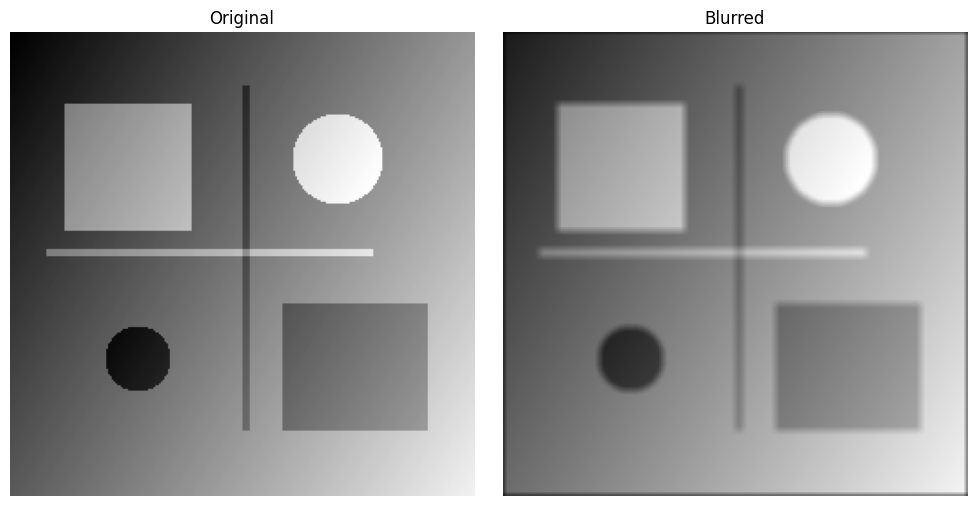

In [13]:
box_kernel = np.ones((5,5), dtype=np.float32)
box_kernel /= box_kernel.sum()

blurred = convolve2d_manual(
    grayscale_img.astype(np.float32),
    box_kernel
)

show_images(
    [grayscale_img, blurred],
    ['Original', 'Blurred'],
    cols=2,
    figsize=(10,5)
)

In [14]:
gaussian_kernel = np.array([
    [1,2,1],
    [2,4,2],
    [1,2,1]
], dtype=np.float32)

gaussian_kernel /= gaussian_kernel.sum()

In [15]:
# TODO: Sinh viên tự hoàn thiện warp affine bằng ánh xạ ngược

def warp_affine_manual(img, matrix, out_shape, interpolation='nearest', fill_value=0):
    """
    Biến đổi affine dùng ánh xạ ngược.

    Pipeline cho mỗi pixel đích (r', c'):
      [x, y, 1]^T = matrix^{-1} @ [c', r', 1]^T
      if (x, y) ngoài biên: gán fill_value
      else: gọi hàm nội suy phù hợp

    Phân biệt cơ chế theo interpolation:
      'nearest'  -> nearest_interpolate(img, x, y)
                    [tích vô hướng 1x1, không cần delta]
      'bilinear' -> bilinear_interpolate(img, x, y)
                    [tích vô hướng 2x2, w = f(delta)]
      'bicubic'  -> bicubic_interpolate(img, x, y)
                    [tích vô hướng 4x4, kernel = R(delta-i) -- thay đổi mỗi pixel]
      'lanczos'  -> lanczos_interpolate(img, x, y)
                    [tích vô hướng (2a)x(2a), kernel = L(delta-i) -- thay đổi mỗi pixel]

    Lưu ý: SSAA dùng hàm riêng warp_affine_ssaa, không qua đây.

    interpolation : 'nearest' | 'bilinear' | 'bicubic' | 'lanczos'
    """
    out_h, out_w = out_shape

    #output img
    output = np.full((out_h, out_w), fill_value, dtype =np.float32)

    # inverse transform
    matrix_inv = np.linalg.inv(matrix)

    # source size
    h, w = img.shape[:2]

    # scan ouput image
    for r_out in range(out_h):
        for c_out in range(out_w):
            
            # homogenous coordinate
            dst = np.array([c_out, r_out, 1], dtype=np.float32)

            #backward mapping
            src = matrix_inv @ dst
            x = src[0]
            y = src[1]

            #outside image
            if x < 0  or x >= w:
                continue
            if y < 0 or y >= h:
                continue
            
            #interpolation
            if interpolation == 'nearest':
                value = nearest_interpolate(img, x, y)

            elif interpolation == 'bilinear':
                value = bilinear_interpolate(img, x, y)

            elif interpolation == 'bicubic':

                value = bicubic_interpolate(img, x, y)

            elif interpolation == 'lanczos':

                value = lanczos_interpolate(img, x, y)
            output[r_out, c_out] = value
    #clamp
    output = np.clip(output, 0, 255) 
    return output.astype(img.dtype)
    raise NotImplementedError


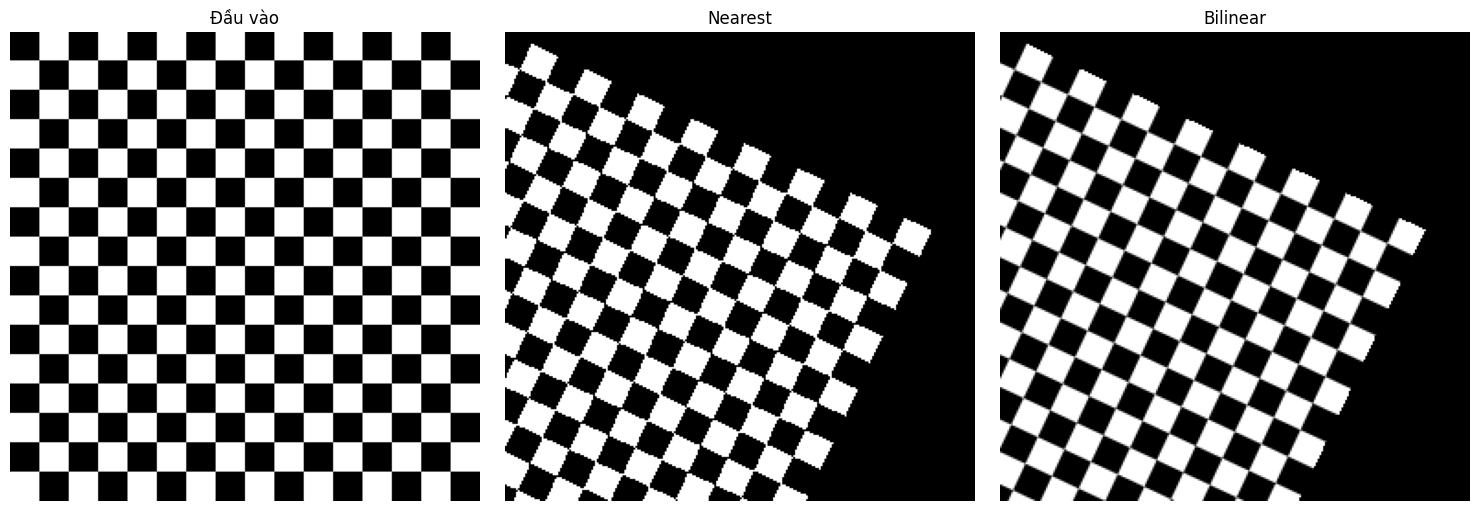

In [16]:
# Ô kiểm tra nhanh Phần A
# Ví dụ khung:
# M = rotation_matrix(25)
# out_nn = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='nearest')
# out_bl = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='bilinear')
# show_images([checkerboard_img, out_nn, out_bl], ['Đầu vào', 'Nearest', 'Bilinear'])
M = rotation_matrix(25)

# nearest
out_nn = warp_affine_manual(
    checkerboard_img.astype(np.float32),
    M,
    checkerboard_img.shape,
    interpolation='nearest'
)

# bilinear
out_bl = warp_affine_manual(
    checkerboard_img.astype(np.float32),
    M,
    checkerboard_img.shape,
    interpolation='bilinear'
)

show_images(
    [
        checkerboard_img,
        out_nn,
        out_bl
    ],
    [
        'Đầu vào',
        'Nearest',
        'Bilinear'
    ],
    cols=3,
    figsize=(15,5)
)

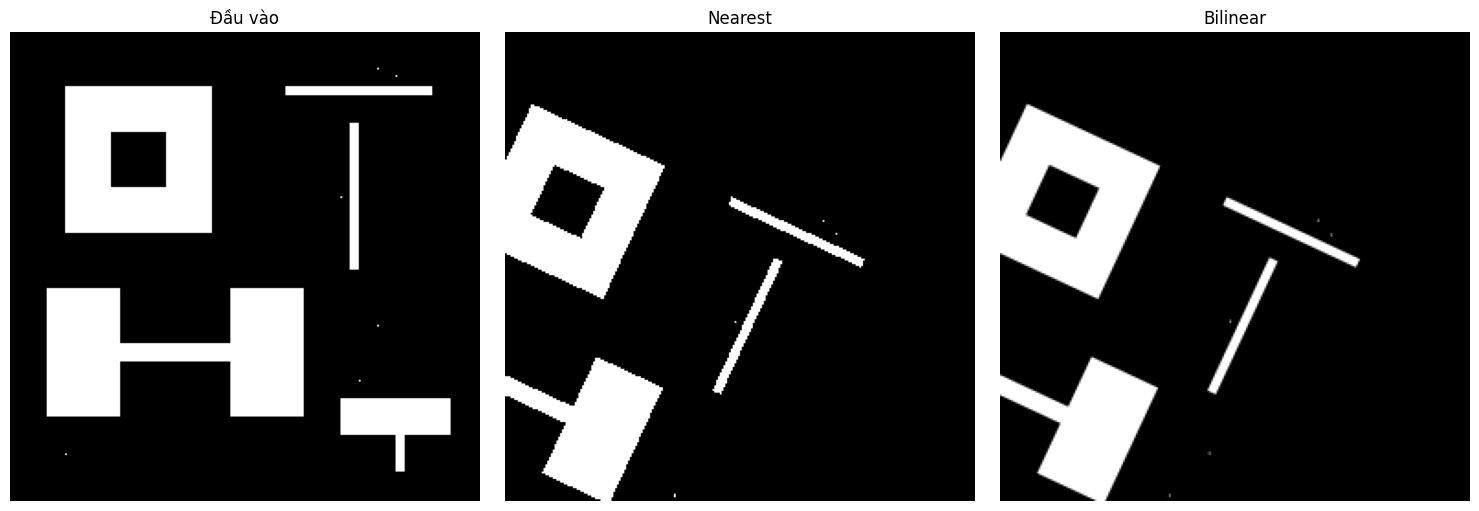

In [27]:
M = rotation_matrix(25)

# nearest
out_nn = warp_affine_manual(
    binary_img.astype(np.float32),
    M,
    binary_img.shape,
    interpolation='nearest'
)

# bilinear
out_bl = warp_affine_manual(
    binary_img.astype(np.float32),
    M,
    grayscale_img.shape,
    interpolation='bilinear'
)

show_images(
    [
        binary_img,
        out_nn,
        out_bl
    ],
    [
        'Đầu vào',
        'Nearest',
        'Bilinear'
    ],
    cols=3,
    figsize=(15,5)
)

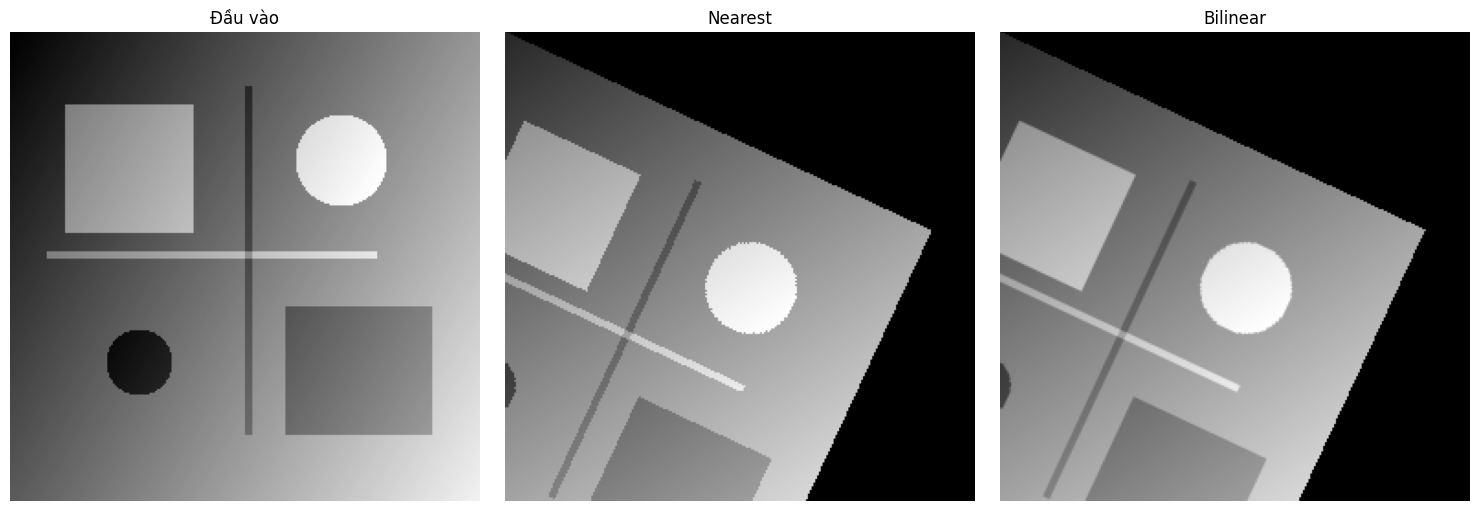

In [17]:
M = rotation_matrix(25)

# nearest
out_nn = warp_affine_manual(
    grayscale_img.astype(np.float32),
    M,
    grayscale_img.shape,
    interpolation='nearest'
)

# bilinear
out_bl = warp_affine_manual(
    grayscale_img.astype(np.float32),
    M,
    grayscale_img.shape,
    interpolation='bilinear'
)

show_images(
    [
        grayscale_img,
        out_nn,
        out_bl
    ],
    [
        'Đầu vào',
        'Nearest',
        'Bilinear'
    ],
    cols=3,
    figsize=(15,5)
)

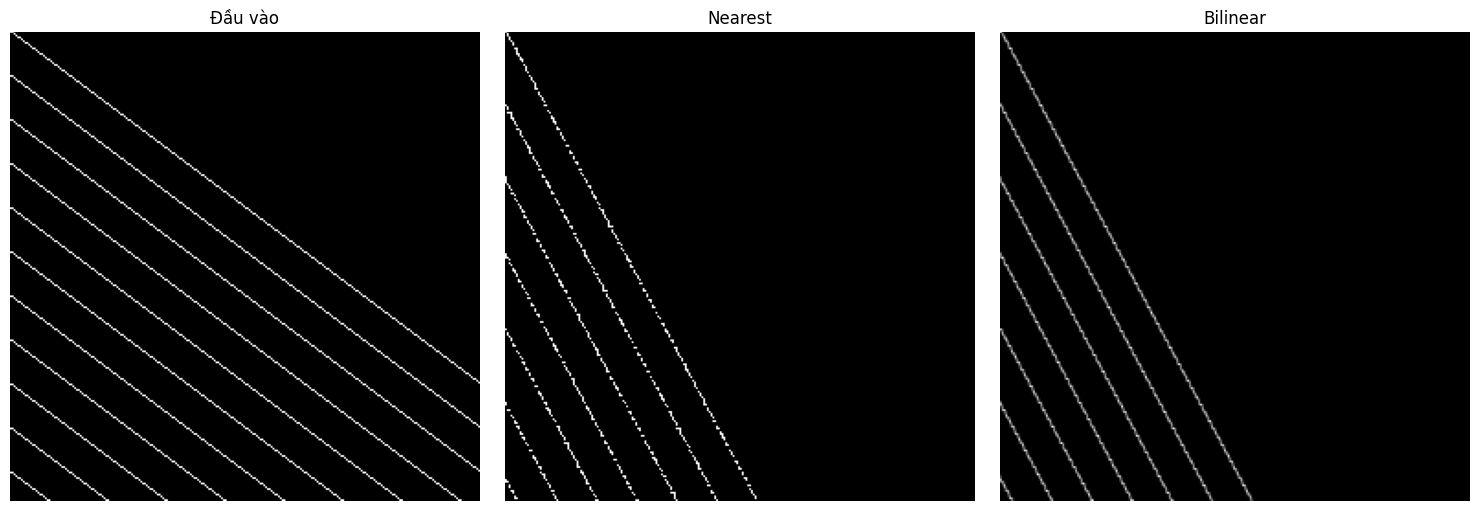

In [18]:

# TEST diagonal lines

M = rotation_matrix(25)

# nearest
out_nn = warp_affine_manual(
    diagonal_img.astype(np.float32),
    M,
    diagonal_img.shape,
    interpolation='nearest'
)

# bilinear
out_bl = warp_affine_manual(
    diagonal_img.astype(np.float32),
    M,
    diagonal_img.shape,
    interpolation='bilinear'
)

show_images(
    [
        diagonal_img,
        out_nn,
        out_bl
    ],
    [
        'Đầu vào',
        'Nearest',
        'Bilinear'
    ],
    cols=3,
    figsize=(15,5)
)

### Nhận xét so sánh Nearest và Bilinear:
* **Nearest-Neighbor:** Giữ được độ tương phản trắng/đen gốc rất tốt, nhưng bị hiện tượng răng cưa (aliasing) cực kỳ nặng. Các đường chéo biên của bàn cờ bị gãy gập thành từng bậc thang vuông vức.
* **Bilinear:** Đã khắc phục được lỗi răng cưa đứt gãy nhờ cơ chế pha trộn pixel, giúp đường chéo trông liền mạch hơn. Tuy nhiên, nhược điểm là làm cho vùng ranh giới giữa ô trắng và đen bị mờ (nhòe) đi đáng kể.
**=> Kết luận:** Bilinear cho viền mượt mắt hơn nhưng phải đánh đổi bằng việc giảm độ sắc nét của ảnh so với Nearest.

## Phần B -- Anti-aliasing qua nội suy nâng cao

Khi xoay hoặc phóng to ảnh, các đường chéo và cạnh cong trông gồ ghề
(răng cưa / jaggies). Nguyên nhân: tọa độ nguồn $(y, x)$ sau ánh xạ ngược
không trùng với lưới pixel -- phần lẻ $\delta$ khác nhau mỗi pixel đích.

### Hai cách chống răng cưa

**Cách 1 -- Tích chập cố định (SSAA):**  
Warp bằng nearest, rồi gọi `convolve2d_manual` với kernel hộp.  
Kernel không thay đổi → có thể dùng `convolve2d_manual` một lần.

**Cách 2 -- Tích vô hướng cục bộ với kernel thay đổi (Bicubic, Lanczos):**  
Bên trong vòng lặp của `warp_affine_manual`, mỗi pixel đích tính
$(\delta_r, \delta_c)$, xây weight vector $w_r, w_c$, rồi thực hiện
tích vô hướng với patch $4\times4$ hoặc $(2a)\times(2a)$.  
Kernel thay đổi mỗi pixel → **không thể** gọi `convolve2d_manual` toàn ảnh.


### Kỹ thuật 1: Supersampling Anti-Aliasing (SSAA) -- tích chập cố định

**Ý tưởng:** Lấy $L^2$ mẫu đều nhau trong diện tích pixel đích, mỗi mẫu
ánh xạ ngược về ảnh nguồn và nội suy bilinear, rồi trung bình.

$$C(r', c') = \frac{1}{L^2}\sum_{m=0}^{L-1}\sum_{n=0}^{L-1}
f\!\left(r'+\frac{m+0.5}{L},\;c'+\frac{n+0.5}{L}\right)$$

**Liên hệ với tích chập:** SSAA tương đương áp bộ lọc hộp $L\times L$
lên ảnh đã warp nearest. Kernel hộp **không phụ thuộc** vào $\delta$ --
nó như nhau tại mọi pixel:
$$K_{\text{box}}^{(L)} = \frac{1}{L^2}\mathbf{1}_{L\times L}$$

Vì vậy `warp_affine_ssaa` có thể được cài đặt theo một trong hai cách:
- **Cách A (khuyến khích):** warp nearest → `convolve2d_manual(warped, K_box)`.
- **Cách B:** vòng lặp $L^2$ mẫu mỗi pixel (theo công thức trên).

Cả hai cho cùng kết quả; Cách A tái sử dụng hàm đã viết.


In [19]:
# TODO: Sinh viên tự cài đặt SSAA

def warp_affine_ssaa(img, matrix, out_shape, L=2, fill_value=0):
    """
    Biến đổi affine với Supersampling Anti-Aliasing.

    Với mỗi pixel đích (r', c'), lấy L*L mẫu con đều nhau trong
    diện tích pixel, ánh xạ ngược từng mẫu con về ảnh nguồn,
    nội suy bilinear, rồi lấy trung bình.

    Gợi ý: offset mẫu con thứ (m, n) tại pixel (r', c') là
        (r' + (m + 0.5) / L,  c' + (n + 0.5) / L)
    trước khi ánh xạ ngược qua matrix^{-1}.

    L : int -- hệ số supersampling (L=2 => 4 mẫu/pixel, L=4 => 16 mẫu/pixel)
    """
    out_h, out_w = out_shape

    #output image
    output = np.full((out_h, out_w), fill_value, dtype=np.float32)

    # inverse transform
    matrix_inv = np.linalg.inv(matrix)

    #source image size
    h, w = img.shape[:2]

    #scan image size
    for r_out in range(out_h):
        for c_out in range(out_w):

            accum = 0.0
            count = 0.0

            # LxL sub-sample
            for m in range(L):
                for n in range(L):

                    #sub pixel position
                    r_sub = r_out + (m + 0.5) / L
                    c_sub = c_out + (n + 0.5) / L

                    # homogeneous coordinate
                    dst = np.array([c_sub, r_sub, 1], dtype=np.float32)

                    # backward mapping
                    src = matrix_inv @ dst

                    x = src[0]
                    y = src[1]

                    #outside image
                    if x < 0 or x >= w:
                        continue
                    if y < 0 or y >= h:
                        continue

                    #bilinear interpolation
                    value = bilinear_interpolate(img, x, y)

                    accum += value
                    count += 1
            #average samples
            if count > 0:
                output[r_out, c_out] = accum / count
    output = np.clip(output, 0, 255)

    return output

    raise NotImplementedError


### Kỹ thuật 2: Bicubic -- tích vô hướng cục bộ $4\times4$

**Ý tưởng:** Dùng cửa sổ $4\times4$ pixel lân cận và hàm trọng số
cubic $R(d)$ (Keys) thay vì trung bình đều.

**Hàm trọng số 1D** ($a = -0.5$):
$$R(d) = \begin{cases}
(a+2)|d|^3 - (a+3)|d|^2 + 1 & |d| \leq 1 \\
a|d|^3 - 5a|d|^2 + 8a|d| - 4a & 1 < |d| < 2 \\
0 & \text{còn lại}
\end{cases}$$

**Tại sao không dùng `convolve2d_manual`?**  
Tại mỗi pixel đích, $\delta_r$ và $\delta_c$ khác nhau.  
Weight vector $\mathbf{w}_r = [R(\delta_r+1),\,R(\delta_r),\,R(\delta_r-1),\,R(\delta_r-2)]$
thay đổi theo $\delta_r$ -- kernel không cố định.  
Phải tính bên trong vòng lặp của `warp_affine_manual`.

**Công thức tích vô hướng cục bộ:**
$$P(y,x) = \mathbf{w}_r^T \cdot I_{\text{patch}} \cdot \mathbf{w}_c$$
trong đó $I_{\text{patch}}$ là ma trận $4\times4$ pixel lân cận.  
Không cần lật kernel (đây là tích vô hướng, không phải tích chập).


In [20]:
# TODO: Sinh viên tự cài đặt Bicubic

def cubic_kernel(d, a=-0.5):
    """
    Hàm trọng số bicubic 1D tại khoảng cách d -- Keys cubic.

    Trả về R(d) theo công thức piecewise.
    Kiểm tra: R(0)=1, R(1)=0, R(1.5)=-0.0625 với a=-0.5.
    """
    d = abs(d)
    # |d| <= 1
    if d <= 1:
        return ((a+2) * d**3 - (a+3) * d**2 + 1)
    
    # 1 < |d| < 2:
    elif d < 2:
        return (a * d**3 - 5 * a * d**2 + 8 * a * d - 4 * a)

    #outside support
    else:
        return 0.0
    raise NotImplementedError


def bicubic_interpolate(img, x, y, a=-0.5):
    """
    Nội suy bicubic tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 4x4 -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - w_r[i] = cubic_kernel(delta_r - i)  cho i in {-1, 0, 1, 2}
    - w_c[j] = cubic_kernel(delta_c - j)  cho j in {-1, 0, 1, 2}
    - Patch P = I[floor(y)-1 : floor(y)+3, floor(x)-1 : floor(x)+3]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng ma trận)

    Không cần lật kernel (khác với convolve2d_manual).
    Clamp kết quả về [0, 255].
    """
    h, w = img.shape

    # floor coordinates
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    #delta 
    dx = x - x0
    dy = y - y0

    # weight vectors
    w_c = np.array([
        cubic_kernel(dx + 1, a),
        cubic_kernel(dx, a),
        cubic_kernel(dx - 1, a),
        cubic_kernel(dx - 2, a)
    ], dtype=np.float32)

    w_r = np.array([
        cubic_kernel(dy + 1, a),
        cubic_kernel(dy, a),
        cubic_kernel(dy - 1, a),
        cubic_kernel(dy - 2, a)
    ], dtype=np.float32)

    # 4x4 patch
    patch = np.zeros((4,4), dtype=np.float32)

    for i in range(4):
        for j in range(4):

            yy = y0 + i - 1
            xx = x0 + j - 1

            #boundary handling
            yy = np.clip(yy, 0, h-1)
            xx = np.clip(xx, 0, w-1)

            patch[i, j] = img[yy, xx]
    #local dot product
    value = w_r @ patch @ w_c

    # clamp
    value = np.clip(value, 0, 255)

    return float(value)

    raise NotImplementedError


### Kỹ thuật 3: Lanczos -- tích vô hướng cục bộ $(2a)\times(2a)$

**Ý tưởng:** Dùng hàm sinc cửa sổ hoá -- xấp xỉ bộ lọc thông thấp lý tưởng.

**Hàm trọng số 1D** ($a = 2$ hoặc $3$):
$$L(x) = \begin{cases}
1 & x = 0 \\
\operatorname{sinc}(x)\cdot\operatorname{sinc}(x/a) & 0 < |x| < a \\
0 & |x| \geq a
\end{cases}$$
với $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$.  
Gợi ý: `np.sinc(x)` trong NumPy đã là sinc chuẩn hoá (đã nhân $\pi$).

**Tại sao không dùng `convolve2d_manual`?**  
Giống bicubic: $\mathbf{w}_r[i] = L(\delta_r - i)$ thay đổi theo $\delta_r$
của từng pixel -- kernel không cố định.

**Công thức tích vô hướng cục bộ có chuẩn hoá:**
$$P(y,x) = \frac{\sum_i\sum_j I[\lfloor y\rfloor+i,\,\lfloor x\rfloor+j]\cdot w_r[i]\cdot w_c[j]}{\sum_i\sum_j w_r[i]\cdot w_c[j]}$$

Chuẩn hoá bắt buộc gần biên ảnh (một số pixel nằm ngoài biên bị bỏ qua,
tổng trọng số nhỏ hơn 1 nếu không chuẩn hoá).


In [21]:
# TODO: Sinh viên tự cài đặt Lanczos

def lanczos_kernel(x, a=3):
    """
    Hàm trọng số Lanczos 1D tại khoảng cách x.

    Trả về L(x) = sinc(x) * sinc(x/a) nếu |x| < a, else 0.
    Gợi ý: np.sinc(x) = sin(pi*x)/(pi*x), đã chuẩn hoá.
    Kiểm tra: L(0)=1, L(1)=0, L(0.5) > 0.
    """

    x = abs(x)

    # center
    if x == 0:
        return 1.0
    #inside support
    elif x < a:
        return(np.sinc(x) * np.sinc(x / a))
    #outside support
    else:
        return 0.0
    
    raise NotImplementedError


def lanczos_interpolate(img, x, y, a=3):
    """
    Nội suy Lanczos tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ (2a)x(2a) CÓ chuẩn hoá -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - i in {-a+1, ..., a}: w_r[i] = lanczos_kernel(delta_r - i, a)
    - j in {-a+1, ..., a}: w_c[j] = lanczos_kernel(delta_c - j, a)
    - Tổng = sum_i sum_j I[floor(y)+i, floor(x)+j] * w_r[i] * w_c[j]
    - Chia cho sum_i sum_j w_r[i] * w_c[j]  (chuẩn hoá -- quan trọng gần biên)

    Không cần lật kernel.
    Clamp kết quả về [0, 255].
    """
    h, w = img.shape[:2]

    #floor coordinate
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    #delta
    dx = x - x0
    dy = y - y0

    #accumulate
    value = 0.0
    weight_sum = 0.0

    #support window
    for i in range(-a+ 1, a+1):
        for j in range(-a+1, a+1):
            yy = y0 + i
            xx = x0 + j

            #skip outside
            if xx < 0 or xx >= w:
                continue
            if yy < 0 or yy >= h:
                continue

            #local varying weights
            w_r = lanczos_kernel(dy - i, a)            
            w_c = lanczos_kernel(dx - j, a)

            w_total = w_r * w_c

            value += img[yy, xx] * w_total

            weight_sum += w_total
    # normalization
    if weight_sum != 0:
        value /= weight_sum
    #clamp
    value = np.clip(value, 0 , 255)    

    return float(value)        
    raise NotImplementedError


### Tích hợp vào warp_affine_manual

Sau khi cài đặt `bicubic_interpolate` và `lanczos_interpolate`,
mở rộng `warp_affine_manual` để tham số `interpolation` chấp nhận
`'bicubic'` và `'lanczos'`.

Sơ đồ dispatch bên trong `warp_affine_manual`:
```
if interpolation == 'nearest':
    val = nearest_interpolate(img, x, y)     # tích vô hướng 1x1
elif interpolation == 'bilinear':
    val = bilinear_interpolate(img, x, y)    # tích vô hướng 2x2
elif interpolation == 'bicubic':
    val = bicubic_interpolate(img, x, y)     # tích vô hướng 4x4, kernel thay đổi
elif interpolation == 'lanczos':
    val = lanczos_interpolate(img, x, y)     # tích vô hướng (2a)^2, kernel thay đổi
```

`warp_affine_ssaa` dùng `convolve2d_manual` riêng -- không đi qua đây.


### So sánh và nhận xét

Chạy **cùng một phép quay** (ví dụ 25°) trên ảnh bàn cờ và ảnh đường chéo
với tất cả các kỹ thuật. Sau đó trả lời các câu hỏi sau trong một ô Markdown:

1. **Răng cưa:** Kỹ thuật nào cho đường chéo mượt nhất? Kỹ thuật nào tệ nhất?
2. **Độ mờ:** Bilinear và bicubic có làm mờ cạnh sắc không? Lanczos có hiện
   tượng "halo" (ringing) gần cạnh không?
3. **Chi phí tính toán:** Ước lượng số phép nhân cần để tính một pixel đích
   cho mỗi kỹ thuật (nearest, bilinear, bicubic, SSAA với $L=2$, Lanczos $a=3$).
4. **Trường hợp sử dụng:** Kỹ thuật nào phù hợp cho ảnh y tế (không được
   làm mờ biên quan trọng)? Kỹ thuật nào phù hợp cho ảnh màu tự nhiên?


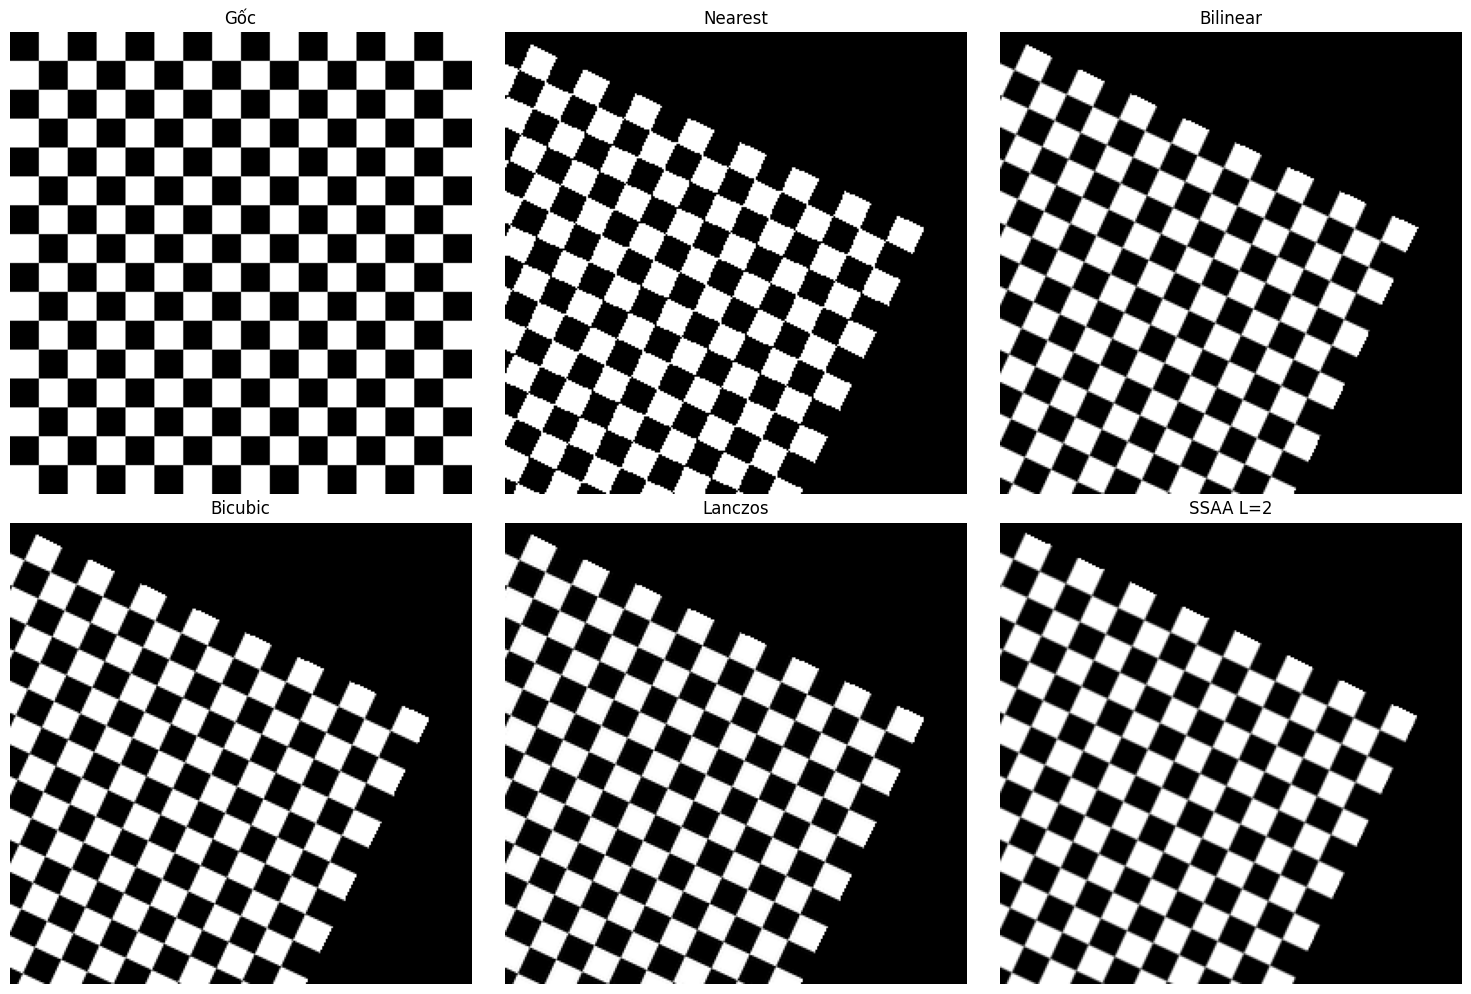

In [ ]:
# Ô thực hành so sánh anti-aliasing
# Sau khi hoàn thiện tất cả các hàm, chạy so sánh ở đây.

# Ví dụ khung:
# M = rotation_matrix(25)
# H, W = checkerboard_img.shape
# img_f = checkerboard_img.astype(np.float32)
#
# out_nn  = warp_affine_manual(img_f, M, (H, W), interpolation='nearest')
# out_bl  = warp_affine_manual(img_f, M, (H, W), interpolation='bilinear')
# out_bc  = warp_affine_manual(img_f, M, (H, W), interpolation='bicubic')
# out_lz  = warp_affine_manual(img_f, M, (H, W), interpolation='lanczos')
# out_ss  = warp_affine_ssaa(img_f, M, (H, W), L=2)
#
# show_images(
#     [checkerboard_img, out_nn, out_bl, out_bc, out_lz, out_ss],
#     titles=['Gốc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
#     cols=3, figsize=(15, 10)
# )

M = rotation_matrix(25)
# Checkerboard

H, W = checkerboard_img.shape

img_f = checkerboard_img.astype(np.float32)

out_nn = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='nearest'
)

out_bl = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bilinear'
)

out_bc = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bicubic'
)

out_lz = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='lanczos'
)

out_ss = warp_affine_ssaa(
    img_f,
    M,
    (H, W),
    L=2
)

show_images(
    [
        checkerboard_img,
        out_nn,
        out_bl,
        out_bc,
        out_lz,
        out_ss
    ],
    titles=[
        'Gốc',
        'Nearest',
        'Bilinear',
        'Bicubic',
        'Lanczos',
        'SSAA L=2'
    ],
    cols=3,
    figsize=(15,10)
)

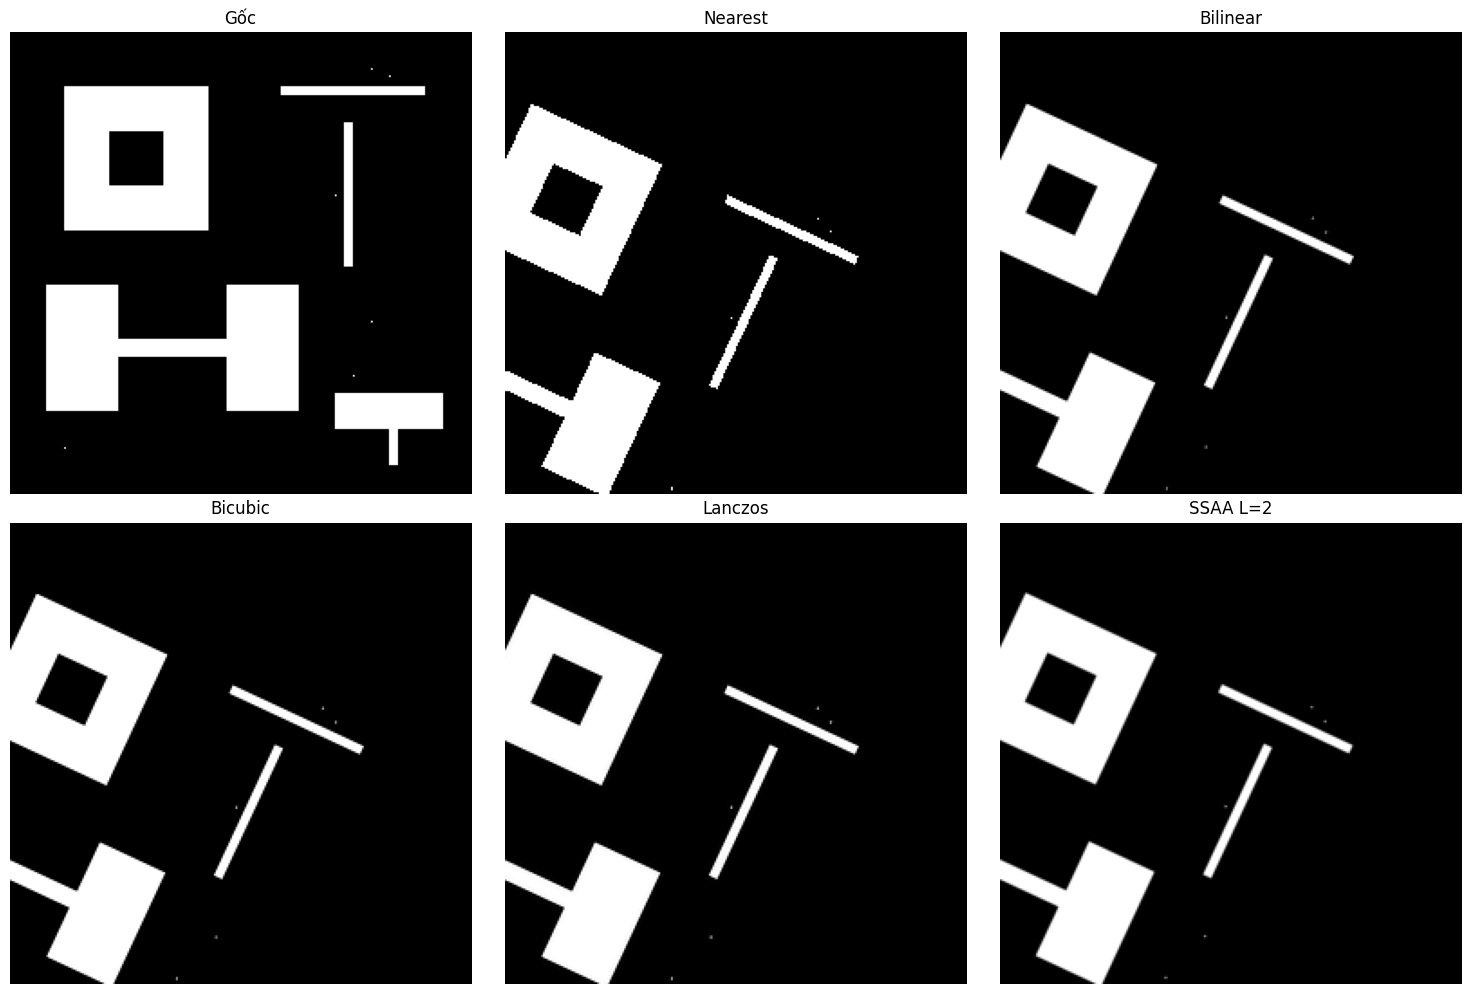

In [28]:
M = rotation_matrix(25)

#binary_img
H, W = binary_img.shape

img_f = binary_img.astype(np.float32)

out_nn = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='nearest'
)

out_bl = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bilinear'
)

out_bc = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bicubic'
)

out_lz = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='lanczos'
)

out_ss = warp_affine_ssaa(
    img_f,
    M,
    (H, W),
    L=2
)

show_images(
    [
        binary_img,
        out_nn,
        out_bl,
        out_bc,
        out_lz,
        out_ss
    ],
    titles=[
        'Gốc',
        'Nearest',
        'Bilinear',
        'Bicubic',
        'Lanczos',
        'SSAA L=2'
    ],
    cols=3,
    figsize=(15,10)
)

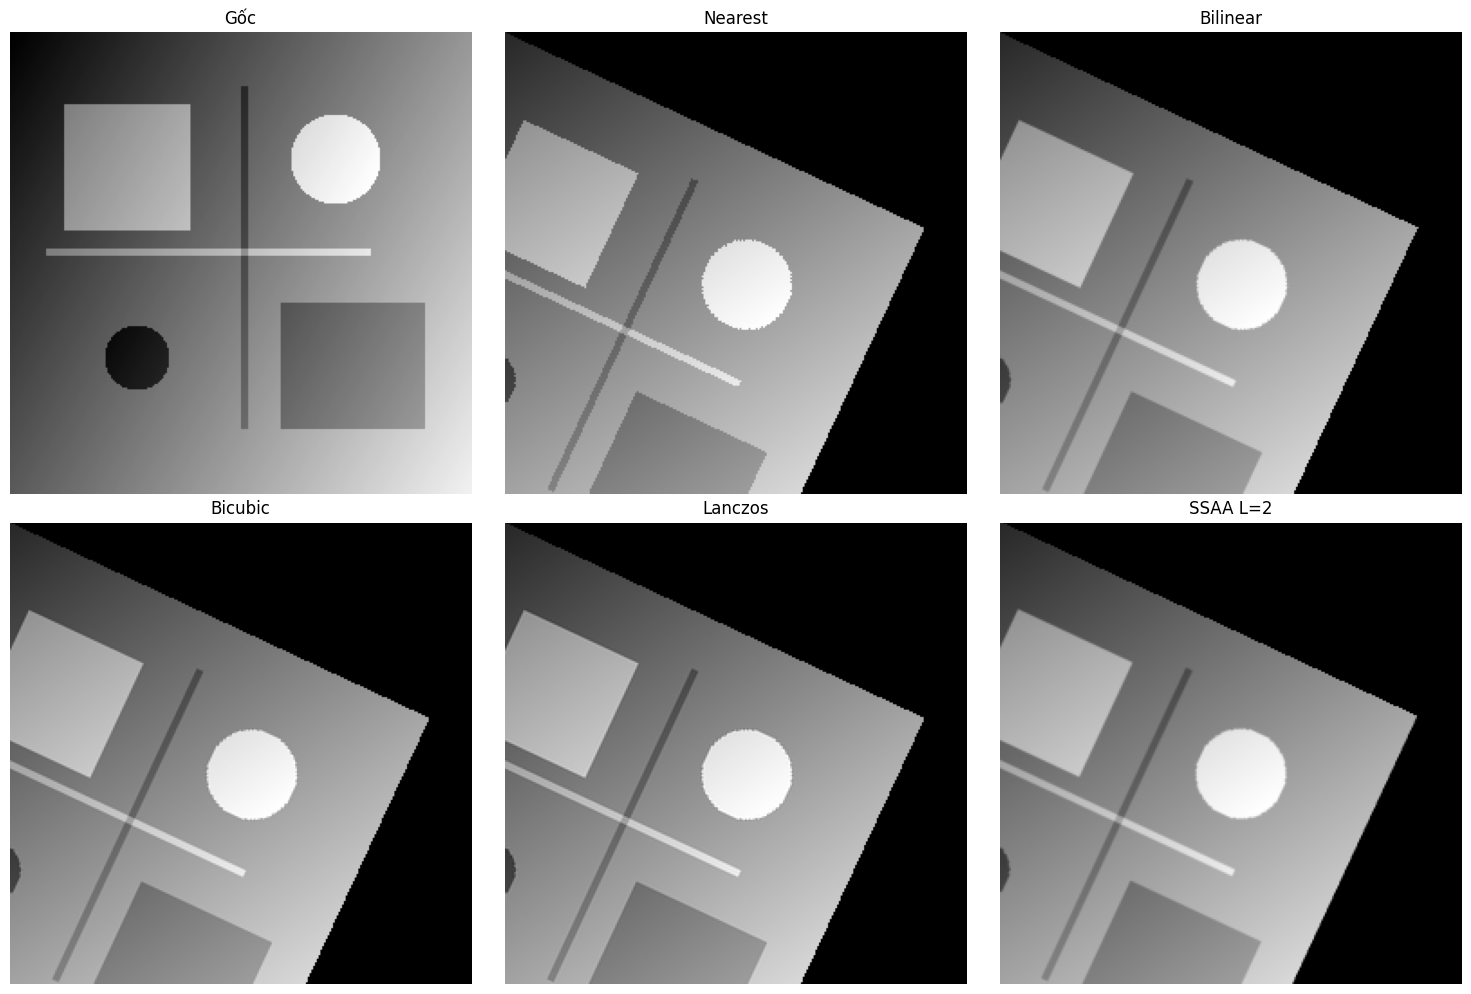

In [29]:
M = rotation_matrix(25)

#grascale_img
H, W = grayscale_img.shape

img_f = grayscale_img.astype(np.float32)

out_nn = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='nearest'
)

out_bl = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bilinear'
)

out_bc = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bicubic'
)

out_lz = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='lanczos'
)

out_ss = warp_affine_ssaa(
    img_f,
    M,
    (H, W),
    L=2
)

show_images(
    [
        grayscale_img,
        out_nn,
        out_bl,
        out_bc,
        out_lz,
        out_ss
    ],
    titles=[
        'Gốc',
        'Nearest',
        'Bilinear',
        'Bicubic',
        'Lanczos',
        'SSAA L=2'
    ],
    cols=3,
    figsize=(15,10)
)

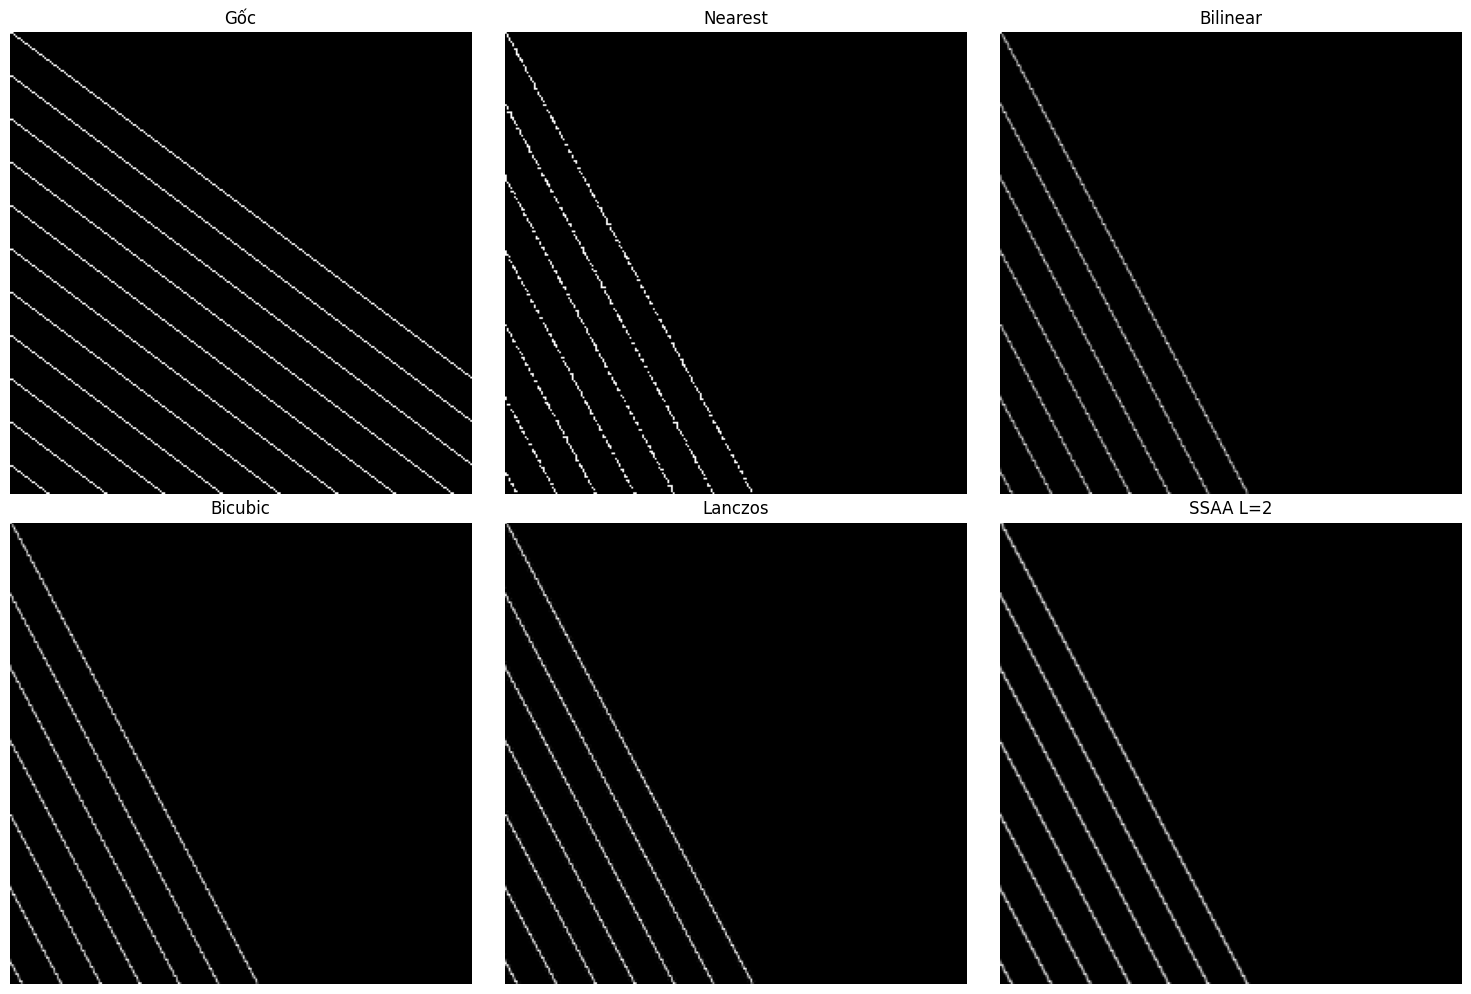

In [30]:
M = rotation_matrix(25)

#diagonal_img
H, W = diagonal_img.shape

img_f = diagonal_img.astype(np.float32)

out_nn = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='nearest'
)

out_bl = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bilinear'
)

out_bc = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='bicubic'
)

out_lz = warp_affine_manual(
    img_f,
    M,
    (H, W),
    interpolation='lanczos'
)

out_ss = warp_affine_ssaa(
    img_f,
    M,
    (H, W),
    L=2
)

show_images(
    [
        diagonal_img,
        out_nn,
        out_bl,
        out_bc,
        out_lz,
        out_ss
    ],
    titles=[
        'Gốc',
        'Nearest',
        'Bilinear',
        'Bicubic',
        'Lanczos',
        'SSAA L=2'
    ],
    cols=3,
    figsize=(15,10)
)

1. Răng cưa (Aliasing)

    - Kỹ thuật cho đường chéo mượt nhất: SSAA với $L=2$ (và Lanczos ở nhóm nội suy thông thường). SSAA xử lý khử răng cưa ở cấp độ sub-pixel (siêu mẫu) giúp làm mịn các góc cạnh chéo một cách tự nhiên nhất.

    - Kỹ thuật tệ nhất: Nearest Neighbor. Do thuật toán chỉ lấy giá trị pixel gần nhất mà không thực hiện bất kỳ phép làm mượt hay tính trung bình nào, hiện tượng răng cưa bậc thang bị lộ rõ nhất.

2. Độ mờ (Blurring) và Hiện tượng Ringing (Halo Effect)

    - Bilinear và Bicubic có làm mờ cạnh sắc không? * Bilinear: Có làm mờ mạnh. Bản chất là bộ lọc thông thấp (low-pass), lấy trung bình tuyến tính của lưới $2\times2$ nên làm nhòe đường biên sắc nét thành một dải xám.

        - Bicubic: Ít làm mờ hơn rất nhiều. Nhờ đa thức bậc ba có các hệ số âm ở vùng lân cận xa (tạo hiệu ứng overshoot), Bicubic "nhấn" lại độ tương phản vùng biên, giúp giữ cạnh sắc tốt hơn Bilinear.

    - Lanczos có hiện tượng "halo" (ringing) gần cạnh không?

        - Có. Đây là đặc trưng kinh điển của Lanczos khi đi qua các cạnh có độ tương phản cực hạn (như vạch đen - trắng của bàn cờ). Bản chất hàm sinc của Lanczos dao động liên tục (gợn sóng) trước khi triệt tiêu về 0. Sự dao động này tạo ra các đường vạch giả lập (gọi là Gibbs hiện tượng hay ringing/halo artifact) xuất hiện như một vầng hào quang mỏng chạy dọc theo cạnh sắc.

3. Chi phí tính toán (Số phép nhân/1 pixel đích)

    - Nearest: 0 (chỉ làm tròn tọa độ).

    - Bilinear ($2\times2$): ~6 - 8 phép nhân.Bicubic ($4\times4$): ~24 - 32 phép nhân.

    - Lanczos ($a=3 \rightarrow 6\times6$): ~50 - 70 phép nhân (tốn thêm chi phí tính hàm lượng giác $\sin$).

    - SSAA ($L=2$): Gấp 4 lần chi phí thuật toán nền (vì phải tính cho 4 sub-pixel).                

4. Trường hợp sử dụng
    - Ảnh y tế (X-ray, CT): Chọn Bicubic hoặc Lanczos vì giữ biên sắc nét, không làm mờ các chi tiết tổn thương nhỏ (loại Bilinear).

    - Ảnh tự nhiên (Phong cảnh, chân dung): Chọn Bicubic (cân bằng tốt nhất giữa chất lượng mượt mà và thời gian xử lý, là chuẩn mặc định của Photoshop/OpenCV).

# Checklist trước khi nộp bài

**Bài tập 1 -- Hình thái học**
- [ ] Đã tự viết hàm padding.
- [ ] Đã tự viết hàm tạo phần tử cấu trúc (rectangle, cross, ellipse).
- [ ] Đã tự viết erosion, dilation, opening, closing, gradient.
- [ ] Đã thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên.
- [ ] Đã có phần nhận xét cho từng kết quả hình thái học.

**Bài tập 2 -- Biến đổi hình học và Anti-aliasing**
- [ ] Đã tự viết `convolve2d_manual` bằng vòng lặp (không dùng hàm có sẵn).
- [ ] Đã tự viết `nearest_interpolate` và `bilinear_interpolate`.
- [ ] Đã tự viết `bicubic_interpolate` (cubic_kernel + 4×4 window).
- [ ] Đã tự viết `lanczos_interpolate` (lanczos_kernel + (2a)×(2a) window).
- [ ] Đã tự viết `warp_affine_ssaa` với supersampling.
- [ ] Đã tự viết `warp_affine_manual` tích hợp đủ bốn phương pháp nội suy.
- [ ] Đã so sánh tất cả kỹ thuật trên cùng một phép biến đổi.
- [ ] Đã trả lời đủ bốn câu hỏi nhận xét trong phần so sánh.
- [ ] Đã dùng ảnh mẫu của giảng viên trong bài nộp chính thức.
- [ ] Đã tuân thủ các hàm bị cấm.
